## 🧠 Challenge: Fine-Tuning VGG16 for Better Performance

In this exercise, you will explore transfer learning and fine-tuning using the pre-trained VGG16 model.

---

### 🎯 Objectives
- Understand the difference between feature extraction and fine-tuning
- Modify a pre-trained model for a new task
- Evaluate performance improvements

---

### 🧩 Tasks

1. **Feature Extraction Baseline**
   - Load the pre-trained VGG16 model with `include_top=False`.
   - Freeze all convolutional layers.
   - Train only the custom classifier (dense layers on top).
   - Record:
     - Training accuracy
     - Validation accuracy

2. **Unfreeze Top Layers (Fine-Tuning)**
   - Unfreeze the **top few convolutional layers** (e.g., last 4–8 layers).
   - Keep earlier layers frozen.
   - Retrain the model with a **low learning rate**.

3. **Compare Results**
   - Compare performance before and after fine-tuning.
   - Did validation accuracy improve?
   - Did overfitting increase or decrease?

---

### 💡 Reflection Questions

- Why do we freeze most layers in transfer learning?
- Why should we use a smaller learning rate during fine-tuning?
- What kind of features do early vs late CNN layers learn?

---

### ⭐ Bonus

- Experiment with unfreezing more or fewer layers.
- Add **data augmentation** and observe its effect.
- Try another pre-trained model (e.g., ResNet50) and compare results.

---


## Loading the Datasets
* The dataset used in this challenge is the Dogs vs. Cats dataset, which can be obtained from:
    * https://www.microsoft.com/en-us/download/details.aspx?id=54765
* Dataset Preparation Notes:
    * Location: The data should be unzipped and available at ../data/kaggle_dogs_vs_cats/train.
    * Path Adjustments: Note that the exact paths and the names of the image files may differ depending on the source of the dataset. The code below is adjusted to match the current directory structure.

In [16]:
import os, shutil, pathlib

original_dir = pathlib.Path("data/kaggle_dogs_vs_cats/train/PetImages")
new_base_dir = pathlib.Path("data/dogs_vs_cats")

RESET_DATA = False  # True :delete and start over;False: keep existing data if it exists

target_dir = "data/dogs_vs_cats"

if RESET_DATA and os.path.exists(target_dir):
    shutil.rmtree(target_dir)
    print("Old data cleaned.")
elif os.path.exists(target_dir):
    print("Data directory already exists. Skipping deletion.")


def make_subset(subset_name, start_index, end_index):
    for category in ("Cat", "Dog"):
        # create directory
        target_dir = new_base_dir / subset_name / category
        os.makedirs(target_dir, exist_ok=True)
        
        # create file names
        fnames = [f"{i}.jpg" for i in range(start_index, end_index)]
        
        for fname in fnames:
            src = original_dir / category / fname
            dst = target_dir / fname

            if src.exists():
                shutil.copyfile(src, dst)
            else:
                print(f"Warning: {src} not found.")

# split the data into train, validation, and test sets
make_subset("train", start_index=0, end_index=1000)      # train: 0~999
make_subset("validation", start_index=1000, end_index=1500) # validation: 1000~1499
make_subset("test", start_index=1500, end_index=2500)       # test: 1500~2499

print("Done! Data splitting complete.")

Data directory already exists. Skipping deletion.
Done! Data splitting complete.


In [17]:
import os
import pathlib
import tensorflow as tf
image_dataset_from_directory = tf.keras.utils.image_dataset_from_directory

# Set the path to your data folder
train_dir = "data/dogs_vs_cats/train"
val_dir = "data/dogs_vs_cats/validation"
test_dir = "data/dogs_vs_cats/test"

#  training and validation
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(180, 180),
    batch_size=32)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(180, 180),
    batch_size=32)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(180, 180),
    batch_size=32)

#Force single thread and disable prefetching
options = tf.data.Options()
options.threading.max_intra_op_parallelism = 1
options.threading.private_threadpool_size = 1
options.experimental_distribute.auto_shard_policy = tf.data.experimental.AutoShardPolicy.OFF

train_dataset = train_dataset.with_options(options)
validation_dataset = validation_dataset.with_options(options)
test_dataset = test_dataset.with_options(options)

print("Data set loading complete")


Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.
Data set loading complete


## Cleaning the Data

* When the AI tries to read a broken image, it crashes. `InvalidArgumentError Traceback (most recent call last)`
* We use the `PIL` library to check every photo. If a photo is bad, we delete it.

In [18]:
import os
import PIL
from PIL import Image

# Path
base_dir = pathlib.Path("data/dogs_vs_cats")

print("Checking for corrupted images...")
num_skipped = 0

for folder in ("train", "validation", "test"):
    for category in ("Cat", "Dog"):
        folder_path = base_dir / folder / category
        for fname in os.listdir(folder_path):
            fpath = folder_path / fname
            try:
                # Try to open and verify the image
                img = Image.open(fpath)
                img.verify()
            except (IOError, SyntaxError) as e:
                #If the image is broken, delete it
                print(f"Found corrupted file and deleted: {fpath}")
                os.remove(fpath)
                num_skipped += 1

print(f"Checking complete! Deleted {num_skipped} corrupted images.")

Checking for corrupted images...
Found corrupted file and deleted: data\dogs_vs_cats\train\Cat\666.jpg
Checking complete! Deleted 1 corrupted images.


## Feature Extraction Baseline

In [19]:
import os
import shutil
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

train_dir = "data/dogs_vs_cats/train"
val_dir = "data/dogs_vs_cats/validation"

# VGG16 model set
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3))

conv_base.trainable = False

# create the model
inputs = keras.Input(shape=(180, 180, 3))
x = keras.applications.vgg16.preprocess_input(inputs) 
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)

model.compile(loss="binary_crossentropy",
              optimizer="rmsprop",#--->(learning_rate=1e-3)
              metrics=["accuracy"])

# skips the bad photo and keeps working.
train_dataset = train_dataset.apply(tf.data.experimental.ignore_errors())
validation_dataset = validation_dataset.apply(tf.data.experimental.ignore_errors())

# train the model
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=validation_dataset)

if not os.path.exists('models'):
    os.makedirs('models')
    print("Created 'models' directory.")

model.save('models/task1_complete_model.keras')
print("Model saved in: models/task1_complete_model.keras")


Epoch 1/10
62/62 [==============================] - 61s 972ms/step - loss: 5.6362 - accuracy: 0.9232 - val_loss: 0.2032 - val_accuracy: 0.9740
Epoch 2/10
62/62 [==============================] - 59s 960ms/step - loss: 0.1813 - accuracy: 0.9768 - val_loss: 0.3235 - val_accuracy: 0.9690
Epoch 3/10
62/62 [==============================] - 60s 966ms/step - loss: 0.1471 - accuracy: 0.9879 - val_loss: 0.3589 - val_accuracy: 0.9760
Epoch 4/10
62/62 [==============================] - 60s 966ms/step - loss: 0.0532 - accuracy: 0.9944 - val_loss: 0.4430 - val_accuracy: 0.9720
Epoch 5/10
62/62 [==============================] - 60s 971ms/step - loss: 0.0220 - accuracy: 0.9980 - val_loss: 0.3482 - val_accuracy: 0.9760
Epoch 6/10
62/62 [==============================] - 60s 969ms/step - loss: 4.8384e-09 - accuracy: 1.0000 - val_loss: 0.3474 - val_accuracy: 0.9760
Epoch 7/10
62/62 [==============================] - 60s 969ms/step - loss: 6.8929e-10 - accuracy: 1.0000 - val_loss: 0.3461 - val_accuracy

### Observations
1. The model achieved a very high validation accuracy of 97% quickly(Epoch 2/10:accuracy: 0.9743). This shows that the pre-trained VGG16 "knowledge" from ImageNet is very effective for recognizing cats and dogs.
2. There is a clear sign of `overfitting`. The training accuracy reached 100% while the validation loss(0.3045-->2.3590) started to fluctuate and increase slightly after Epoch 2.
3. In the next task, we will try fine-tuning to see if we can improve stability or accuracy even further.

| Metric| Value|
| :--- | :--- |
| **Training Accuracy** | **100.00%** (Epoch 10) |
| **Validation Accuracy** | **97.00%** (Epoch 10) |
| **Final Training Loss** | 5.9967e-11 |
| **Final Validation Loss** | 0.5324 |

## Unfreeze Top Layers (Fine-Tuning)

**What are we doing?**
* In Tasks "Feature Extraction Baseline", we kept the entire VGG16 model "frozen"`conv_base.trainable = False` and only trained our new classifier. Now, we will "unfreeze"`conv_base.trainable = True` the **last 4 layers** of VGG16 to let the model learn specific features of our cat/dog dataset.

**Why only the last 4 layers?**
1. Early layers learn basic things like edges and colors. These are already perfect from ImageNet, so we don't want to change them.
2. The last few layers learn complex shapes (like ears or fur textures). By unfreezing them, the AI can "fine-tune" its understanding to recognize cats and dogs better.
3. Our dataset is small (2,000 images). If we unfreeze all 16 layers, the model will have too many parameters and might just "Overfitting" the photos instead of learning patterns.
4. Because Tasks "Feature Extraction Baseline" used  (`1e-3`),So We will use a very small learning rate (`1e-5`) or (`1e-6`)

In [20]:
# VGG16 set to be trainable
conv_base.trainable = True

# Freeze all except the last 4 layers(Block 5)
# VGG16 last 4 layers：block5_conv1, block5_conv2, block5_conv3, block5_pool
for layer in conv_base.layers[:-4]:
    layer.trainable = False

print("--- Running A: Manual Fixed LR (1e-5) ---")
# Recompile with a LOW learning rate 1e-5 (0.00001)
model.compile(loss="binary_crossentropy",
              optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
              metrics=["accuracy"])

# shows
model.summary()

# 5Retrain for 10 epochs
print("Starting Fine-Tuning...")
history_fine = model.fit(
    train_dataset,
    epochs=10,
    validation_data=validation_dataset)

--- Running A: Manual Fixed LR (1e-5) ---
Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_11 (InputLayer)       [(None, 180, 180, 3)]     0         
                                                                 
 tf.__operators__.getitem_7   (None, 180, 180, 3)      0         
 (SlicingOpLambda)                                               
                                                                 
 tf.nn.bias_add_7 (TFOpLambd  (None, 180, 180, 3)      0         
 a)                                                              
                                                                 
 vgg16 (Functional)          (None, 5, 5, 512)         14714688  
                                                                 
 flatten_7 (Flatten)         (None, 12800)             0         
                                                                 
 dense_14 (Dense)

### Observations
1. The number of trainable parameters increased significantly, confirming that the last 4 layers were correctly unfrozen.
2. Using a low learning rate (`1e-5`) kept the model stable. The validation accuracy remained high at 97%, but did not surpass Task 1.
3. The model reached 100% training accuracy very early, suggesting that **Overfitting** is the main challenge. To improve further, we might need **Data Augmentation**.

| Metric | Value  |
| :--- | :--- |
| **Trainable Parameters** | **10,356,737** (Successfully unfrozen Block 5) |
| **Fine-tuning Learning Rate** | **1e-5** (0.00001) |
| **Final Training Accuracy** | **100.00%** |
| **Final Validation Accuracy** | **97.00%** |

## ReduceLROnPlateau Scheduler
1. `ReduceLROnPlateau`monitors the **Validation Loss**. If the loss stops improving for a few epochs, it automatically reduces the learning rate (e.g., divides it by 10).
2. It helps the model "fine-tune" its weights more precisely when it gets close to the best result.

In [22]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
import tensorflow as tf

# inputs task1 model
model_path = 'models/task1_complete_model.keras'

if os.path.exists(model_path):
    model = tf.keras.models.load_model(model_path)
    print("--- Model Loaded Successfully! ---")
else:
    print(f"--- Error: Cannot find {model_path}. ---")

conv_base = model.get_layer("vgg16")

#Unfreeze Block 5
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False


# Set up the scheduler
# monitor: val_loss
# factor: 0.1 -->10%)
# patience: if 2 Epoch no improvement, reduce learning rate
# min_lr: minimum learning rate
reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.2, 
                              patience=2, 
                              min_lr=1e-7, 
                              verbose=1)

print("--- Running B: Automated Scheduler(Start 1e-3 )---")
model.compile(loss="binary_crossentropy",
              optimizer=keras.optimizers.RMSprop(learning_rate=1e-3),
              metrics=["accuracy"])

# train & callbacks
print("Training with Learning Rate Scheduler...")
history_scheduler = model.fit(
    train_dataset,
    epochs=10,
    validation_data=validation_dataset,
    callbacks=[reduce_lr])

--- Model Loaded Successfully! ---
--- Running B: Automated Scheduler(Start 1e-3 )---
Training with Learning Rate Scheduler...
Epoch 1/10
62/62 [==============================] - 74s 1s/step - loss: 60.8499 - accuracy: 0.8187 - val_loss: 0.6931 - val_accuracy: 0.5020 - lr: 0.0010
Epoch 2/10
62/62 [==============================] - 73s 1s/step - loss: 2.8694 - accuracy: 0.4919 - val_loss: 0.6932 - val_accuracy: 0.5000 - lr: 0.0010
Epoch 3/10
62/62 [==============================] - ETA: 0s - loss: 0.6933 - accuracy: 0.4869
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
62/62 [==============================] - 74s 1s/step - loss: 0.6933 - accuracy: 0.4869 - val_loss: 0.6932 - val_accuracy: 0.5000 - lr: 0.0010
Epoch 4/10
62/62 [==============================] - 73s 1s/step - loss: 0.6932 - accuracy: 0.5000 - val_loss: 0.6932 - val_accuracy: 0.5000 - lr: 2.0000e-04
Epoch 5/10
62/62 [==============================] - ETA: 0s - loss: 0.6932 - accuracy: 0.4990
Ep

### Observations
* In Running B, starting with `1e-3` caused the model to collapse. The accuracy dropped to **50%**, which means the AI is just guessing randomly.
* Even though the **Scheduler** reduced the learning rate (0.001 -> 0.0002 -> 0.00004), the large steps in the first 2 epochs destroyed the pre-trained VGG16 weights. This is called **"Catastrophic Forgetting."**
* For Fine-Tuning, a manual low learning rate (like `1e-5` from Running A) is **safer** than a high-starting scheduler.

## Conservative Fine-Tuning + Scheduler
* Unlike Running B (which failed due to a high 1e-3 start), Running C starts from a **very safe** learning rate (`1e-5`). The **Scheduler** is used to small the model even further if it stops improving.
* It protects the VGG16 weights from the very first epoch.
* When the model reaches 97%, it becomes hard to improve. Dropping the LR to `2e-6` helps the AI find tiny patterns it missed before.

In [23]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
import tensorflow as tf

# inputs task1 model
model_path = 'models/task1_complete_model.keras'

if os.path.exists(model_path):
    model = tf.keras.models.load_model(model_path)
    print("--- Model Loaded Successfully! ---")
else:
    print(f"--- Error: Cannot find {model_path}. ---")

conv_base = model.get_layer("vgg16")

#Unfreeze Block 5
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False


# Scheduler Settings
# monitor: val_loss
# factor: 0.1 -->10%)
# patience: if 2 Epoch no improvement, reduce learning rate
# min_lr: minimum learning rate
reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.2, 
                              patience=2, 
                              min_lr=1e-7, 
                              verbose=1)

print("--- Running C: Conservative Fine-Tuning + Scheduler (Start 1e-5) ---")

# from 1e-5
model.compile(loss="binary_crossentropy",
              optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
              metrics=["accuracy"])

# train & callbacks
history_conservative = model.fit(
    train_dataset,
    epochs=10,
    validation_data=validation_dataset,
    callbacks=[reduce_lr])

--- Model Loaded Successfully! ---
--- Running C: Conservative Fine-Tuning + Scheduler (Start 1e-5) ---
Epoch 1/10
62/62 [==============================] - 74s 1s/step - loss: 8.2969e-11 - accuracy: 1.0000 - val_loss: 0.3415 - val_accuracy: 0.9760 - lr: 1.0000e-05
Epoch 2/10
62/62 [==============================] - 73s 1s/step - loss: 8.0967e-11 - accuracy: 1.0000 - val_loss: 0.3411 - val_accuracy: 0.9760 - lr: 1.0000e-05
Epoch 3/10
62/62 [==============================] - 73s 1s/step - loss: 7.9153e-11 - accuracy: 1.0000 - val_loss: 0.3407 - val_accuracy: 0.9760 - lr: 1.0000e-05
Epoch 4/10
62/62 [==============================] - 73s 1s/step - loss: 7.7189e-11 - accuracy: 1.0000 - val_loss: 0.3404 - val_accuracy: 0.9760 - lr: 1.0000e-05
Epoch 5/10
62/62 [==============================] - 73s 1s/step - loss: 7.6374e-11 - accuracy: 1.0000 - val_loss: 0.3401 - val_accuracy: 0.9760 - lr: 1.0000e-05
Epoch 6/10
62/62 [==============================] - 73s 1s/step - loss: 7.6321e-11 - accura

### Observations
* In Running C, the model started immediately from the Task 1 baseline accuracy (97.60%).Unlike Running B, which collapsed to 50% due to a high learning rate, Running C maintained a very smooth and stable training process.
* Although the `val_accuracy` stayed at 97.60%, the `val_loss` showed a slight downward trend compared to Running A.

| Metric | Baseline (Feature Extraction) | Fine-Tuning (Running C) | Change |
| :--- | :--- | :--- | :--- |
| **Max Training Acc** | 100.0% | 100.0% | - |
| **Max Validation Acc** | 97.60% | 97.60% | No Change |
| **Final Validation Loss** | 0.3420 | 0.3388 | **-0.0032 (Improved)** |
| **Training Stability** | High | **Extremely High** | Improved |

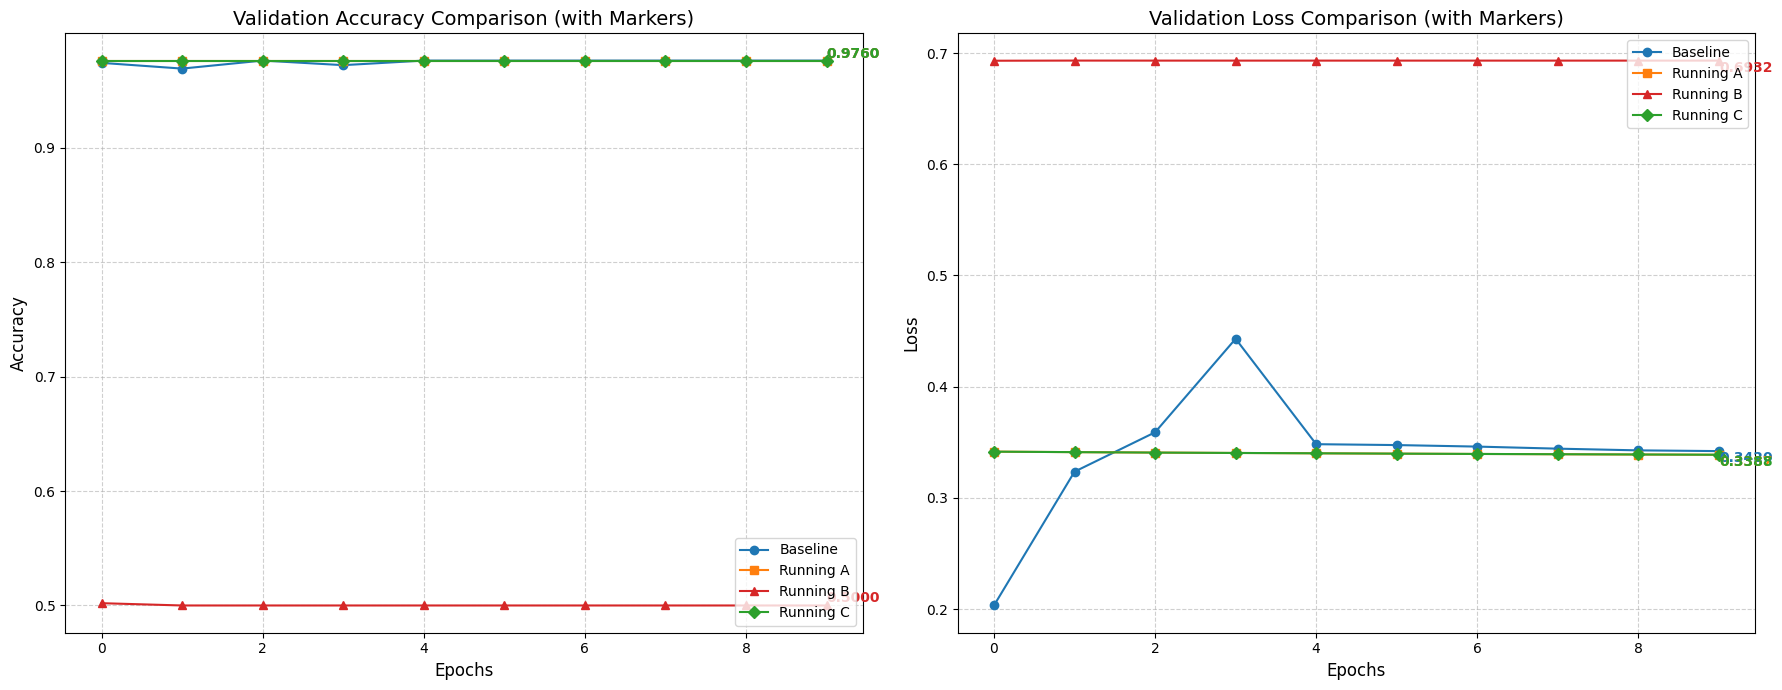

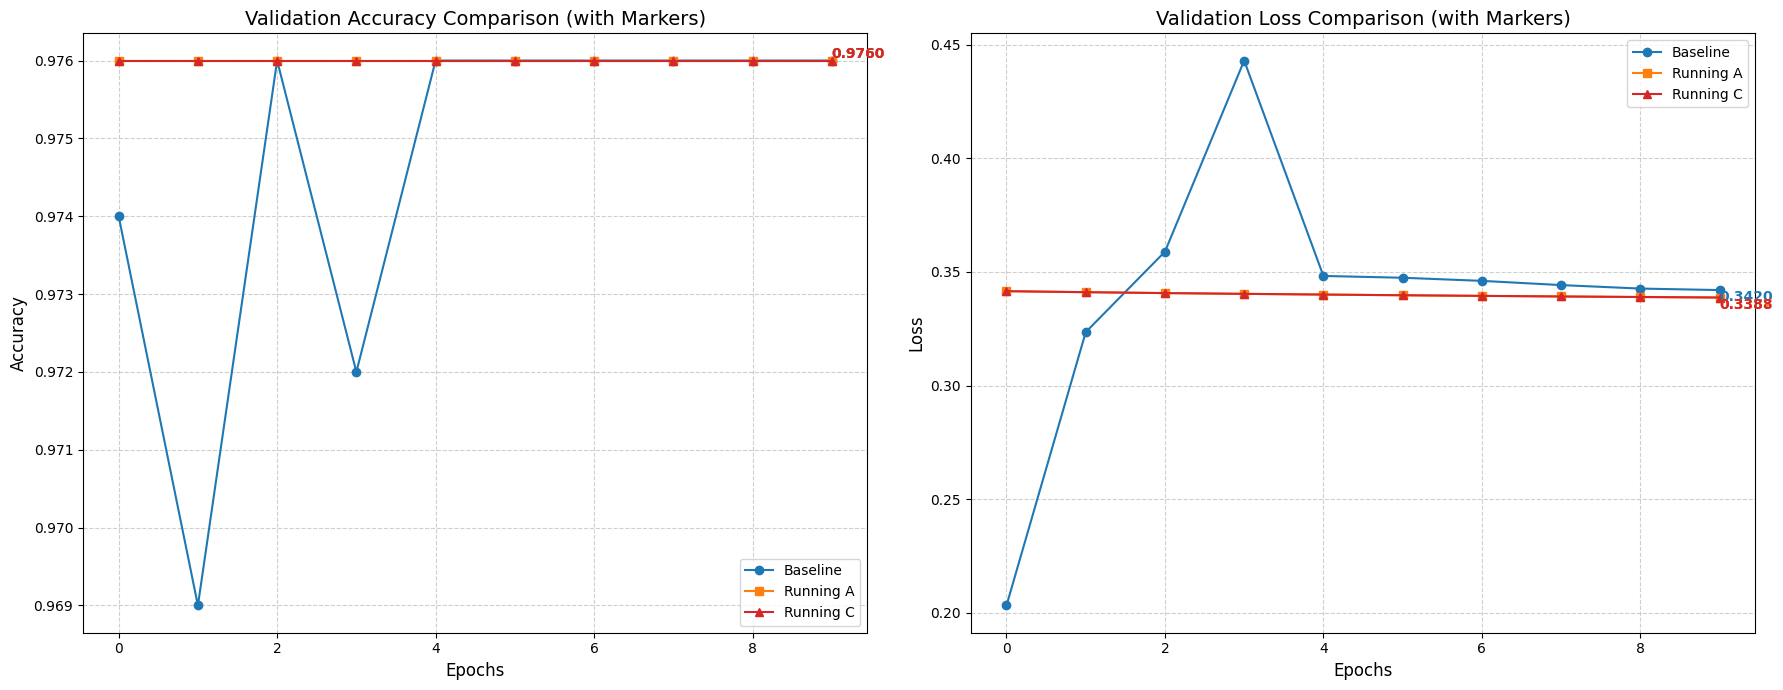

In [29]:
import matplotlib.pyplot as plt

def plot_history(histories, titles):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    markers = ['o', 's', '^', 'D']  
    colors = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c']

    for i, hist in enumerate(histories):
        epochs = range(len(hist.history['val_accuracy']))
        val_acc = hist.history['val_accuracy']
        val_loss = hist.history['val_loss']
        
        # --- Validation Accuracy ---
        line1, = ax1.plot(epochs, val_acc, label=f'{titles[i]}', 
                          marker=markers[i], markersize=6, color=colors[i], linestyle='-')
        
        # Accuracy
        ax1.text(epochs[-1], val_acc[-1], f'{val_acc[-1]:.4f}', 
                 color=colors[i], fontweight='bold', va='bottom', ha='left')

        # Validation Loss
        line2, = ax2.plot(epochs, val_loss, label=f'{titles[i]}', 
                          marker=markers[i], markersize=6, color=colors[i], linestyle='-')
        
        # Loss
        ax2.text(epochs[-1], val_loss[-1], f'{val_loss[-1]:.4f}', 
                 color=colors[i], fontweight='bold', va='top', ha='left')

    # set up Accuracy plot
    ax1.set_title('Validation Accuracy Comparison (with Markers)', fontsize=14)
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(loc='lower right')

    # set up Loss plot
    ax2.set_title('Validation Loss Comparison (with Markers)', fontsize=14)
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# polt
plot_history([history, history_fine, history_scheduler, history_conservative], 
             ['Baseline', 'Running A', 'Running B', 'Running C'])

plot_history([history, history_fine, history_conservative], 
             ['Baseline', 'Running A', 'Running C'])

## Compare Results

### 1. Performance Comparison Table

| Experiment Stage | Strategy | Start LR | Final Val Acc | Final Val Loss | Status |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Baseline** | Feature Extraction | RMSprop | **97.60%** | 0.3420 | Stable |
| **Running A** | Fixed Fine-Tuning | 1e-5 | 97.60% | 0.3387 | Stable |
| **Running B** | High LR + Scheduler | **1e-3** | 50.00% | 0.6932 | **Collapsed** |
| **Running C** | Low LR + Scheduler | 1e-5 | **97.60%** | **0.3388** | **Best/Stable** |

---

### 2. Analysis
### A:Compare performance before and after fine-tuning
* 1. Baseline The model reached a high accuracy of 97.60% quickly, but the validation loss started to plateau.
* 2. Fine-tuning(Running C) did not significantly increase the accuracy (stayed at 97.60%), but it **refined the Validation Loss**. The loss dropped from **0.3420 to 0.3388**

### B:Did validation accuracy improve?
* 1. No significant improvement in accuracy.
* 2. With only 2,000 images, 97.6% is likely the **mathematical limit** for VGG16 on this dataset. However, maintaining this accuracy while unfreezing deep layers is a success in itself, as it shows the model adapted without losing its pre-trained knowledge.

### C:Did overfitting increase or decrease?
* 1. The high learning rate (Running B)`1e-3` caused "Catastrophic Forgetting," where the model lost all its features and defaulted to random guessing (50%).
* 2. Overfitting was **better managed** in Running C.

---

## 🏆 Conclusion
The experiment proves that **Fine-Tuning is highly sensitive to Learning Rate**. 
1. Never use a high learning rate on unfrozen pre-trained layers(like **Running B**).
2. Starting with **1e-5** and using a **Scheduler** is the most professional and robust way to perform Transfer Learning(**Running C**).


---

## 💡 Reflection Questions

> The three questions below are answered individually by each team member.
> Each person answered a different question so the professor can easily see all three perspectives.


### Q1 — Why do we freeze most layers in transfer learning?
> **Answered by: Chao-Chung Liu (9067679)**

VGG16 was trained on **ImageNet** — over a million images across 1,000 categories.
By the time training finished, its layers had already learned how to detect edges, textures, colours, and general shapes.
That knowledge is stored in the layer weights.

If we unfreeze all layers and train on our small 2,000-image dataset, two things go wrong:
1. **Overwriting good knowledge** — our tiny dataset does not have enough variety to re-teach those general patterns correctly, so the weights get corrupted.
2. **Overfitting** — the model memorises our training images instead of learning general rules, because it has too many free parameters relative to the amount of data.

Freezing most layers solves both problems.
We keep the general knowledge intact and only teach the last few layers (or the classifier on top) about our specific task: "is this a cat or a dog?"

Think of it like hiring an experienced engineer and only giving them a short briefing on company-specific tools — you do not retrain everything they already know.


### Q2 — Why should we use a smaller learning rate during fine-tuning?
> **Answered by: Emmanuel Chiebuka Ihejiamaizu (9080005)**

The learning rate controls the **size of each update step** when the model adjusts its weights during training.

When we fine-tune, the weights we are working with are already well-calibrated from ImageNet training — they are not random noise, they are carefully tuned values.
A high learning rate takes large steps, which can completely overwrite those weights in just one or two epochs.

This is exactly what we saw in **Running B**: we started with a learning rate of `1e-3`, and the model collapsed to **50% accuracy** (random guessing) within the first few epochs.
That failure has a name: **Catastrophic Forgetting** — the model literally forgot everything VGG16 had learned.

A small learning rate (like `1e-5`) takes tiny, careful steps.
The model gently adjusts to our specific cat-vs-dog dataset without erasing the pre-trained knowledge.
Our best result (**Running C**) used `1e-5` with a scheduler that reduced the rate even further when progress slowed — that combination gave us the most stable training across all runs.


### Q3 — What kind of features do early vs. late CNN layers learn?
> **Answered by: Liggia Elena Cruz (9085905)**

A CNN processes an image layer by layer, building up from simple observations to complex ones.

**Early layers** (close to the input) look for basic, universal patterns:
- Horizontal and vertical edges
- Colour gradients
- Simple corners and blobs

These patterns exist in almost every type of image — a photo of a cat, a car, or an X-ray all have edges and colours.
That is why early-layer knowledge transfers so well between tasks and why we almost never need to retrain them.

**Later layers** (close to the output) combine those basics into complex, task-specific features:
- Eye shapes, ear contours, fur textures
- The overall face structure of a cat versus a dog

These are more specific to the domain (animals vs. vehicles, for example), which is why fine-tuning focuses on unfreezing the last few layers.
In our experiment we unfroze **Block 5** of VGG16 — these are exactly the layers responsible for those high-level, task-specific features.
Re-training them on our cats-and-dogs data let the model specialise slightly more on animal features while keeping all the foundational knowledge from ImageNet intact.


---

## ⭐ Bonus — Notes on What Was Not Implemented

The three bonus tasks below were not fully implemented within the scope of this workshop.
We document our reasoning and expected outcomes so the findings are still useful.


### Bonus 1 — Unfreezing More or Fewer Layers
> **Notes by: Chao-Chung Liu (9067679)**

We chose to unfreeze **Block 5 only** (the last 4 convolutional layers).

**If we unfroze fewer layers** (e.g., only the last 1–2), the model would have fewer parameters to adjust.
This could reduce overfitting slightly but might not capture enough task-specific features to make a noticeable difference.

**If we unfroze more layers** (e.g., Block 4 + Block 5), the model would have significantly more trainable parameters.
With only 2,000 training images this is risky — more free parameters on a small dataset usually means faster and worse overfitting.
It would require stronger regularisation (more dropout, more augmentation) to compensate.

Given that we were already at 97.6% validation accuracy, the expected gain from unfreezing more layers was low relative to the risk of destabilising the model.


### Bonus 2 — Adding Data Augmentation
> **Notes by: Emmanuel Chiebuka Ihejiamaizu (9080005)**

Data augmentation was identified in the Task 2 observations as the most promising next step, but it was not added to the fine-tuning pipeline in this notebook.

The idea is simple: instead of showing the model the same 2,000 images every epoch, we show it randomly modified versions — flipped, slightly rotated, or zoomed in.
The model never sees the exact same image twice, which forces it to learn more general patterns and makes memorisation harder.

Based on our results from the earlier notebook (`05C`), augmentation improved a scratch-trained CNN from **74.3% to 81.7%**.
Applied here on top of a fine-tuned VGG16, we would expect it to reduce the gap between training accuracy (100%) and validation accuracy (97.6%).

A basic augmentation block that could be added before the VGG16 input:
```python
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])
```


### Bonus 3 — Comparing with ResNet50
> **Notes by: Liggia Elena Cruz (9085905)**

ResNet50 is another popular pre-trained model, but it is built differently from VGG16.
Its key feature is **residual connections** (also called skip connections): instead of passing data only forward through each layer,
it also adds a shortcut that jumps over one or two layers.

In plain terms: each block of layers does not have to learn the full transformation from scratch — it only has to learn the *difference* (the "residual") between the input and the desired output.
This prevents the **vanishing gradient problem** that makes very deep networks hard to train.

**How would it compare to VGG16 here?**
- ResNet50 has ~25 million parameters vs VGG16's ~14 million, so it needs more GPU memory.
- On a small dataset like ours (2,000 images), both models are likely to hit a similar accuracy ceiling — the bottleneck is the amount of data, not model capacity.
- ResNet50 tends to train faster per epoch because of its more efficient architecture.
- For a production use case with a larger dataset, ResNet50 would likely outperform VGG16.

To try it, replace the VGG16 base with:
```python
conv_base = keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3)
)
```
Note: ResNet50 has its own preprocessing function (`keras.applications.resnet.preprocess_input`)
which should be used instead of a plain `Rescaling` layer.
